## Data preparation and exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("../data/data.xlsx")

In [3]:
# df.shape
# df.info()
# df.isna().sum()
# df.duplicated().sum()
# df[["Quantity", "UnitPrice"]].describe()
# print(df["InvoiceNo"].astype(str).str.startswith("C").sum())
# print((df["Quantity"] <= 0).sum())
# print((df["UnitPrice"] <= 0).sum())
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())
print(df["CustomerID"].nunique())
print(df["InvoiceNo"].nunique())
print(df["StockCode"].nunique())
print(df["Country"].value_counts().head(10))

2010-12-01 08:26:00
2011-12-09 12:50:00
4372
25900
4070
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


## Data Cleaning:

In [9]:
df = df.drop_duplicates()
print(df.shape)
indexes = df[df["Quantity"] <= 0].index
df = df.drop(index=indexes)
print(df.shape)
df = df.dropna(subset=["CustomerID"])
print(df.shape)
ind = df[df["InvoiceNo"].astype(str).str.startswith("C")].index
df = df.drop(index=ind)
print(df.shape)
ind = df[df["UnitPrice"] <= 0].index
df = df.drop(index=ind)
print(df.shape)
df["CustomerID"] = df["CustomerID"].astype(int)
df["CustomerID"].dtype

mask = df["StockCode"].astype(str).str[:5].str.isdigit()
df[~mask]["StockCode"].value_counts()
df = df[mask]
print(df.shape)

(392692, 8)
(392692, 8)
(392692, 8)
(392692, 8)
(392692, 8)
(391150, 8)


## RFM

In [37]:
from datetime import datetime
df["Amount"] = df["UnitPrice"] * df["Quantity"]

df["InvoiceDate"].max()
reference_date = datetime(2011, 12, 10)
reference_date
# reference_date - df["InvoiceDate"].max()
rfm = df.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", "max"),
    Frequency = ("InvoiceNo", "nunique"),
    Monetary = ("Amount", "sum"),
)
rfm["Recency"] = (reference_date - rfm["Recency"]).dt.days
rfm = rfm.reset_index()
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,18,1,1457.55
4,12350,310,1,294.40
...,...,...,...,...
4329,18280,277,1,180.60
4330,18281,180,1,80.82
4331,18282,7,2,178.05
4332,18283,3,16,2039.58


## Cluestring Preparation:

np.float64(1.2426864615841866)

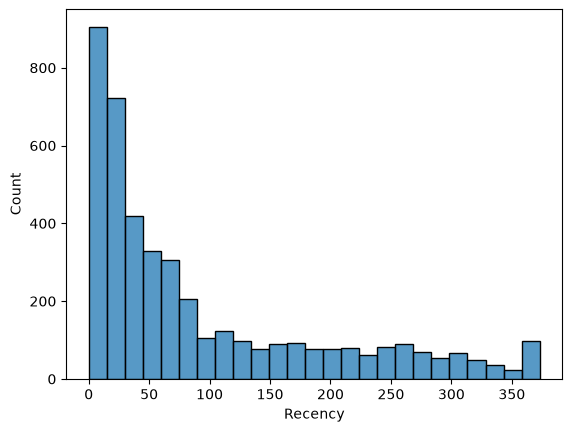

In [ ]:
sns.histplot(rfm, x="Recency")
# most costumers baught are recent 
# skew > 0 which means its right-skewed
rfm["Recency"].skew()


np.float64(11.949414516742257)

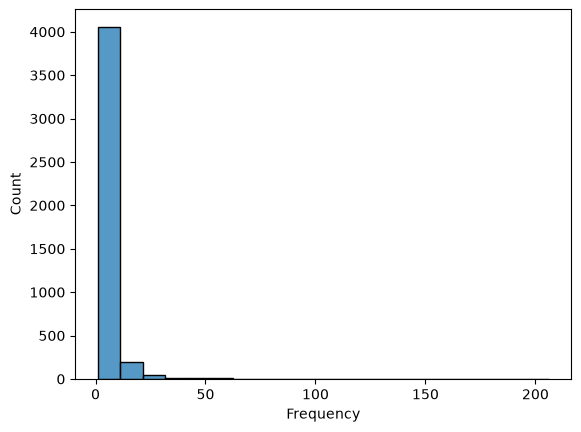

In [ ]:
sns.histplot(rfm, x="Frequency", bins=20)
# skew > 0 which means its right-skewed
rfm["Frequency"].skew()


np.float64(19.578006249138994)

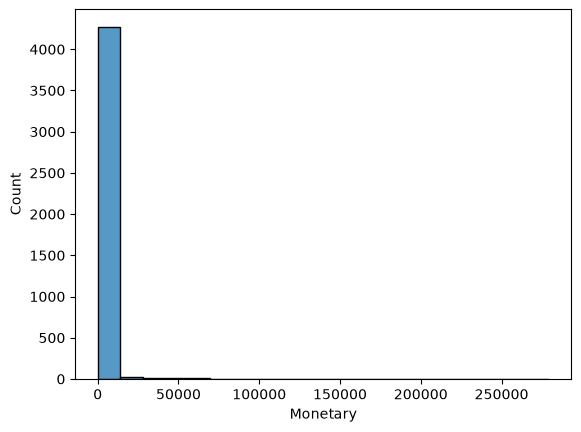

In [51]:
sns.histplot(rfm, x="Monetary", bins=20)
# skew > 0 which means its right-skewed
rfm["Monetary"].skew()


## Log Transformation:

Recency       1.242686
Frequency    11.949415
Monetary     19.578006
dtype: float64


Recency       5.924256
Frequency     5.332719
Monetary     12.539465
dtype: float64

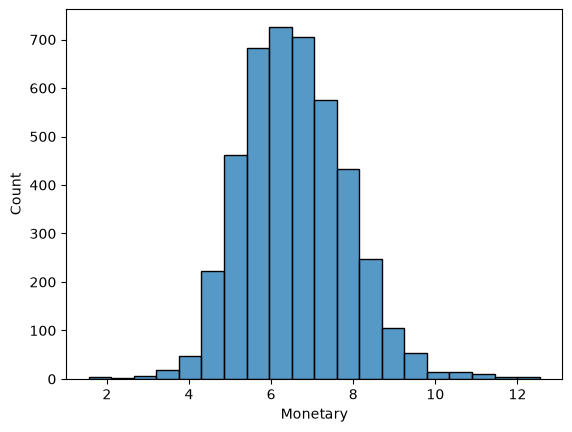

In [ ]:
rfm_log = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])
sns.histplot(rfm_log, x="Monetary", bins=20)
print(rfm[["Recency", "Frequency", "Monetary"]].skew())
rfm_log[["Recency", "Frequency", "Monetary"]].skew()


## Standarization:

In [ ]:
from sklearn.preprocessing import StandardScaler

rfm_standarized = StandardScaler().fit_transform(rfm_log)

rfm_standarized = pd.DataFrame(rfm_standarized, columns=["Recency", "Frequency", "Monetary"])
print(rfm_standarized.mean())
print(rfm_standarized.std())


Recency      7.025094e-16
Frequency   -3.852735e-17
Monetary     5.049542e-16
dtype: float64
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64
Recency      3.802431
Frequency    1.341639
Monetary     6.575495
dtype: float64
Recency      1.384076
Frequency    0.681783
Monetary     1.255017
dtype: float64
